In [1]:
print("Hello World!!")

Hello World!!


In [20]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv(r"/Users/developer/Documents/Current Project/Python/DevArena /DevArena-Week-9/house_data.csv")
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [4]:
df.shape

(1000, 8)

## Preprocessing

In [5]:
df_1 = df.copy()

In [6]:
df_1['House_Price'] = round(df_1['House_Price'], 2)
df_1

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,262382.85
1,4272,3,3,2016,4.753014,1,6,985260.85
2,3592,1,2,2016,3.634823,0,9,777977.39
3,966,1,2,1977,2.730667,1,8,229698.92
4,4926,2,1,1993,4.699073,0,8,1041740.86
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,701494.00
996,3179,1,2,1999,2.977123,1,10,683723.16
997,2606,4,2,1962,4.055067,0,2,572024.02
998,4723,5,2,1950,1.930921,0,7,964865.30


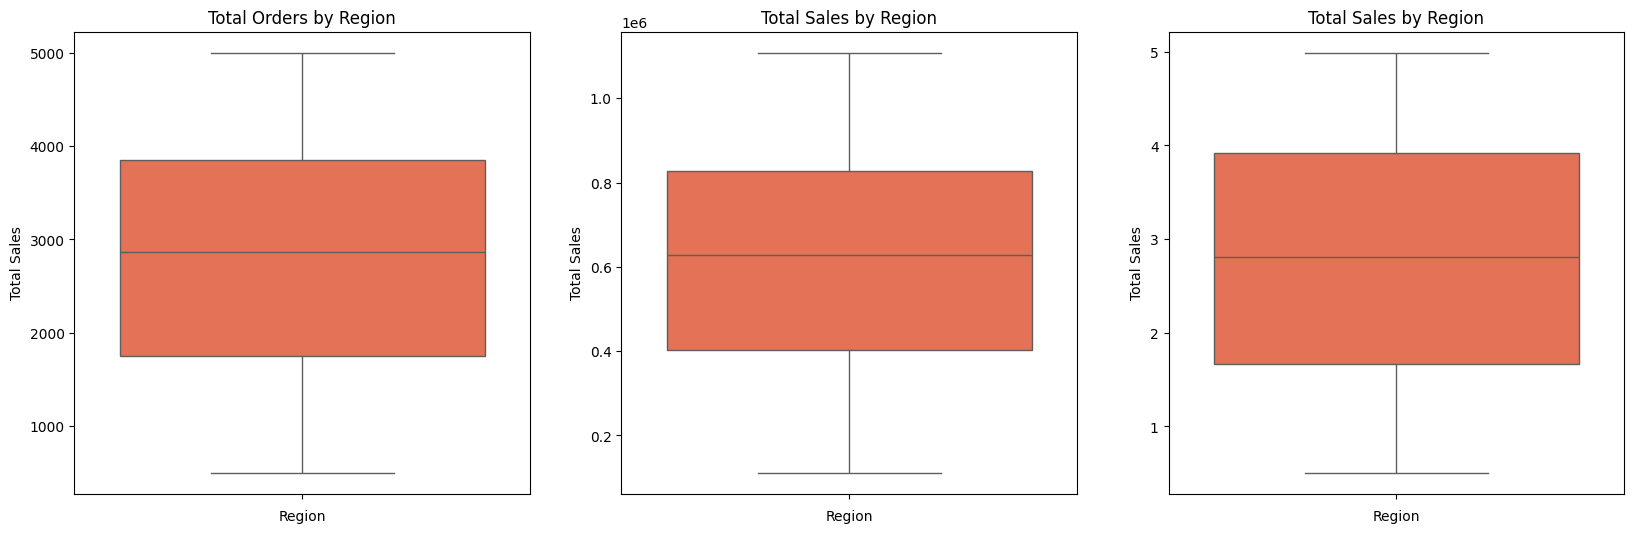

In [7]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
sns.boxplot(data= df_1['Square_Footage'], color='#FA643F')
plt.title('Total Orders by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.subplot(1, 3, 2)
sns.boxplot(data= df_1['House_Price'], color='#FA643F')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.subplot(1, 3, 3)
sns.boxplot(data= df_1['Lot_Size'], color='#FA643F')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.show()

## Model Training

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X = df_1.drop('House_Price', axis=1)
y = df_1['House_Price']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
model = LinearRegression()

In [13]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report

In [16]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 100639938.75013787
R^2 Score: 0.9984347014340322
Mean Absolute Error: 8042.459209095764


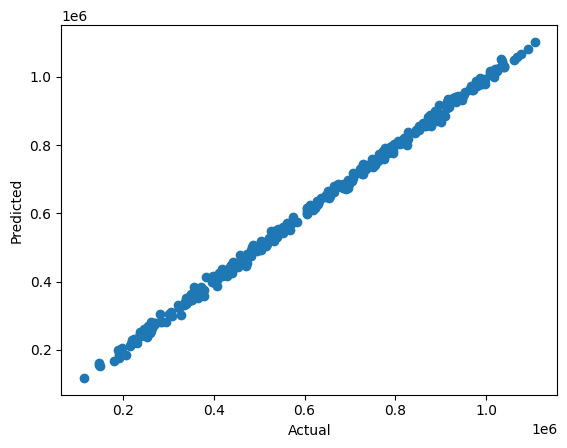

In [17]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()